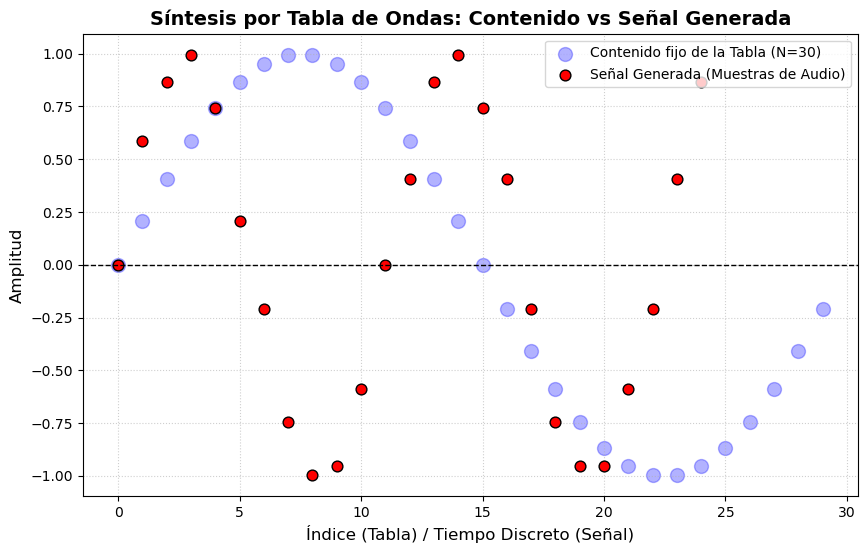

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SIMULACIÓN DE LA CREACIÓN DE LA TABLA (Constructor C++) ---
N = 30  # Tamaño de la tabla (pequeño para que se distingan las pelotitas)
indices_tabla = np.arange(N)
# Generamos un ciclo completo de seno
valores_tabla = np.sin(2 * np.pi * indices_tabla / N)

# --- 2. SIMULACIÓN DE LA GENERACIÓN DE LA SEÑAL (synthesize() C++) ---
num_muestras_audio = 25  # Cuántas muestras de audio vamos a simular
step_fase = 2.7  # Incremento de fase (simula una frecuencia media-alta)
phase_actual = 0.0
muestras_senal_generada = []
indices_tiempo_audio = np.arange(num_muestras_audio)

for i in range(num_muestras_audio):
    # Simulamos el método de redondeo al entero más cercano: (int)(phase + 0.5)
    indice_redondeado = int(phase_actual + 0.5)
    
    # Bucle circular (while phase >= tbl.size())
    indice_redondeado = indice_redondeado % N
    
    # "Búsqueda" en tabla y guardado de la muestra
    muestras_senal_generada.append(valores_tabla[indice_redondeado])
    
    # Avance de la fase
    phase_actual += step_fase

# --- 3. GENERACIÓN DE LA GRÁFICA CON "PELOTITAS" (Scatter plots) ---
plt.figure(figsize=(10, 6))

# Dibujamos primero el contenido de la tabla en el fondo (Pelotitas Azules)
plt.scatter(indices_tabla, valores_tabla, 
            color='blue', 
            alpha=0.3, 
            s=100, # Tamaño grande
            label='Contenido fijo de la Tabla (N=30)',
            zorder=1)

# Dibujamos las muestras de audio generadas (Pelotitas Rojas con borde)
plt.scatter(indices_tiempo_audio, muestras_senal_generada, 
            color='red', 
            marker='o', 
            edgecolors='black', 
            s=60, # Tamaño mediano
            label='Señal Generada (Muestras de Audio)',
            zorder=2) # zorder=2 asegura que las rojas estén encima de las azules

# --- Estética de la gráfica para la memoria ---
plt.title("Síntesis por Tabla de Ondas: Contenido vs Señal Generada", fontsize=14, fontweight='bold')
plt.xlabel("Índice (Tabla) / Tiempo Discreto (Señal)", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Línea de cero
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Guardar la imagen para el README/Memoria
plt.savefig("grafica_tabla_seno.png", dpi=300, bbox_inches='tight')

plt.show()